#### 1. Vad menas med curse of dimensionality.
Ju fler dimensioner, desto glesare sprids observationerna ut och desto mer data krävs. Avstånd mellan punkter blir stora och förvånansvärt lika, vilket gör att metoder som bygger på avstånd fungerar sämre. Risken för överanpassning ökar också.

#### 2. Vad är dimensionsreducering och varför görs det?
Att minska antalet variabler men behålla så mycket information som möjligt. Görs för att motverka curse of dimensionality, snabba upp träningen, kunna visualisera data, minska brus och hantera korrelerade variabler.

#### 3. Förklara översiktligt hur PCA fungerar. Använd figur 5.4 på sidan 224 i din förklaring.
PCA skapar nya variabler som är kombinationer av de gamla. Första komponenten pekar i riktningen där datan varierar mest, andra i riktningen med näst mest varians och vinkelrätt mot den första, och så vidare. Eftersom komponenterna är sorterade efter varians kan man behålla de första och kasta resten. Figur 5.4 visar detta: av tre möjliga linjer att projicera på ger C1 den bredaste spridningen och bevarar mest information, medan den prickade linjen trycker ihop punkterna så att de nästan hamnar på varandra. Variablerna måste skalas först.

#### 5. Stina påstår att man i maskininlärning alltid vill ha modeller som genomför så bra prediktioner som möjligt. Kalle påstår att det inte riktigt stämmer eftersom tid också är en viktig aspekt. Både för själva modellträningen och för själva prediktionerna. Vad säger du?
Kalle har rätt. Träningstiden spelar roll när modellen ska tränas om ofta, och prediktionstiden är ofta ännu viktigare — ett bedrägerisystem har millisekunder på sig. Andra faktorer som minnesåtgång och tolkbarhet räknas också. En enkel modell i drift är mer värd än en avancerad modell som aldrig produktionssätts.

#### 6. Efter att vi genomfört en PCA, vad händer med tolkningen av variablerna?
Tolkbarheten försvinner till stor del. Komponenterna är viktade summor av alla ursprungliga variabler, så man kan inte längre säga vad en enhets ökning betyder i verkligheten. Modellen går från white box mot black box. PCA passar därför när prediktionen är målet, inte förklaringen.

#### 8. Förklara vad nedanstående kod gör.

In [1]:
import numpy as np
from sklearn.decomposition import PCA

X = np.random.rand(1000, 3)
print(X[0:5])

pca = PCA(n_components=2)
X2D = pca.fit_transform(X)
print(X2D[0:5])

X3D_inv = pca.inverse_transform(X2D)
print(np.allclose(X3D_inv, X))

[[0.64172164 0.68158206 0.18448455]
 [0.62365903 0.51959634 0.5775373 ]
 [0.60894163 0.01339961 0.44947663]
 [0.98520812 0.04575893 0.58742407]
 [0.33228224 0.04169309 0.90234661]]
[[-0.21363882  0.18061207]
 [ 0.00598135  0.12889449]
 [-0.33777213 -0.17069078]
 [-0.38276672  0.17838334]
 [ 0.13503069 -0.32884891]]
False


Koden demonstrerar att dimensionsreducering innebär informationsförlust.

- `np.random.rand(1000, 3)` skapar 1 000 rader med 3 slumpmässiga variabler 
  mellan 0 och 1
- `PCA(n_components=2).fit_transform(X)` hittar de två riktningar där datan 
  varierar mest och projicerar datan på dem. Resultatet har fortfarande 1 000 
  rader men bara 2 kolumner, och värdena är nya koordinater i komponentrummet — 
  inte de ursprungliga variablerna
- `inverse_transform(X2D)` räknar tillbaka till 3 dimensioner
- `np.allclose(X3D_inv, X)` ger **False**: den återskapade datan är nära den 
  ursprungliga men inte identisk

Den tredje komponenten kastades bort, och den informationen går inte att få 
tillbaka. Projektionen är enkelriktad.

Slumpmässig data är ett särskilt dåligt fall för PCA. Variablerna är 
okorrelerade, så variansen fördelas jämnt över alla tre riktningarna och det 
finns ingen "oviktig" riktning att kasta. PCA fungerar bäst när variablerna 
är korrelerade.

#### 9. PCA på car_price_dataset.csv

Jämförelse av modeller med och utan PCA.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error, r2_score
import time

cars = pd.read_csv("../data/car_price_dataset.csv", sep=";")
print(cars.shape)
print(cars.columns.tolist())

(10000, 10)
['Brand', 'Model', 'Year', 'Engine_Size', 'Fuel_Type', 'Transmission', 'Mileage', 'Doors', 'Owner_Count', 'Price']


In [3]:
# Model har 30 unika värden och täcks i praktiken av Brand — droppas
cars = cars.drop(columns="Model")
cars = pd.get_dummies(cars, columns=["Brand", "Fuel_Type", "Transmission"],
                      drop_first=True, dtype=int)

X = cars.drop(columns="Price")
y = cars["Price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print(X.shape[1], "variabler efter encoding")

19 variabler efter encoding


In [4]:
# Utan PCA
for name, model in [("Linjär regression", LinearRegression()),
                    ("Random Forest", RandomForestRegressor(n_estimators=100, random_state=42))]:
    t = time.time()
    model.fit(X_train_s, y_train)
    pred = model.predict(X_test_s)
    print(f"UTAN PCA {name}: RMSE {root_mean_squared_error(y_test, pred):.0f}, "
          f"R² {r2_score(y_test, pred):.4f}, {time.time()-t:.1f}s")

UTAN PCA Linjär regression: RMSE 65, R² 0.9995, 0.0s
UTAN PCA Random Forest: RMSE 525, R² 0.9700, 1.7s


In [5]:
pca = PCA(n_components=0.95).fit(X_train_s)
print(f"{pca.n_components_} komponenter behövs för 95 % av variansen "
      f"(av {X_train_s.shape[1]} variabler)")

X_train_p = pca.transform(X_train_s)
X_test_p = pca.transform(X_test_s)

16 komponenter behövs för 95 % av variansen (av 19 variabler)


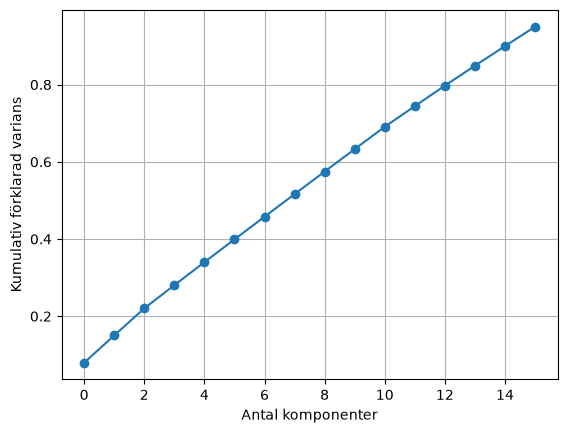

[0.08  0.071 0.07  0.06  0.06  0.059]


In [6]:
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker="o")
plt.xlabel("Antal komponenter")
plt.ylabel("Kumulativ förklarad varians")
plt.grid(True)
plt.show()

print(np.round(PCA().fit(X_train_s).explained_variance_ratio_[:6], 3))

In [7]:
# Med PCA
for name, model in [("Linjär regression", LinearRegression()),
                    ("Random Forest", RandomForestRegressor(n_estimators=100, random_state=42))]:
    t = time.time()
    model.fit(X_train_p, y_train)
    pred = model.predict(X_test_p)
    print(f"MED PCA {name}: RMSE {root_mean_squared_error(y_test, pred):.0f}, "
          f"R² {r2_score(y_test, pred):.4f}, {time.time()-t:.1f}s")

MED PCA Linjär regression: RMSE 754, R² 0.9381, 0.0s
MED PCA Random Forest: RMSE 890, R² 0.9139, 4.7s


Resultatet blev sämre med PCA. Linjär regression gick från RMSE 65 till 754, Random Forest från 525 till 890. PCA behövde 16 av 19 komponenter för 95 % av variansen, vilket visar att variablerna är i stort sett okorrelerade — då finns inget att komprimera. Det mesta är dessutom dummy-variabler, som per definition är oberoende. PCA ignorerar också y och maximerar bara varians i X.